# Task 1 (Phase 2): Term Deposit Subscription Prediction

## Problem Statement
Predict whether a bank customer will subscribe to a term deposit based on
marketing campaign data. We use Random Forest Classifier with SHAP
explainability to understand model predictions.

## Dataset
- Source: Kaggle (Bank Marketing Dataset — UCI)
- Rows: 41,188 | Columns: 21
- Target: y (yes = subscribed, no = not subscribed)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_curve, auc
import shap




In [5]:
df = pd.read_csv('/content/bank-additional-full.csv', sep=';')
print("Shape:", df.shape)
print("\nCols:", df.columns.tolist())
print("\nFirst 5 rows")
df.head()

Shape: (41188, 21)

Cols: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

First 5 rows


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
# Check missing values
print("Missing Values:\n", df.isnull().sum())

# Check target column value counts
print("\nTarget Column Distribution:")
print(df['y'].value_counts())

Missing Values:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Target Column Distribution:
y
no     36548
yes     4640
Name: count, dtype: int64


In [7]:
# Encode Categorical Columns
print(df.select_dtypes(include='object').columns.tolist())

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [8]:
# Encode all categorical columns using LabelEncoder
le = LabelEncoder()
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Data after encoding:")
df.head()

Data after encoding:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


# EDA — Visualizations

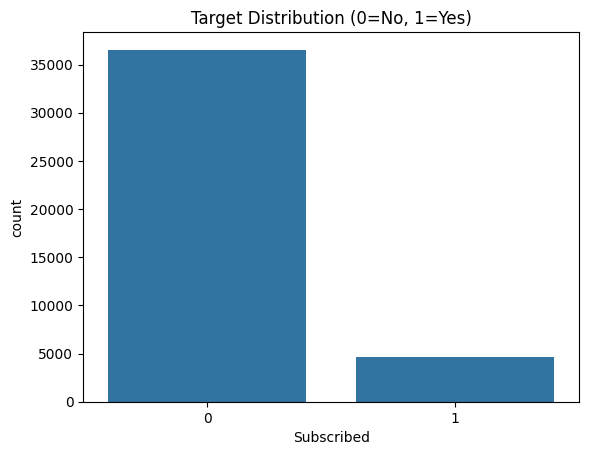

In [10]:
# 1. Target Distribution
fig, ax = plt.subplots()
sns.countplot(x='y', data=df, ax=ax)
ax.set_title('Target Distribution (0=No, 1=Yes)')
ax.set_xlabel('Subscribed')
plt.show()

/tmp/ipykernel_664/1972574683.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No', 'Yes'])


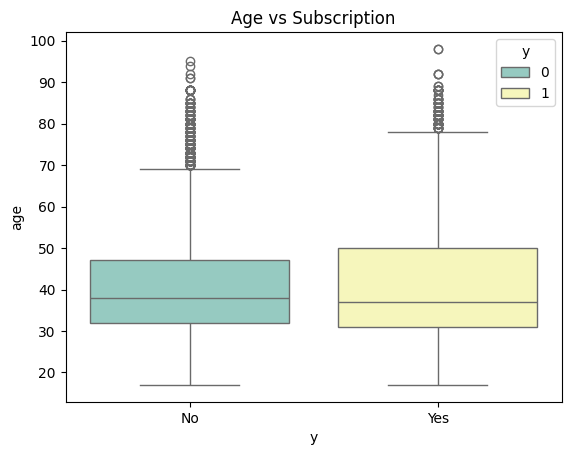

In [11]:
# 2. Age Distribution by Target
# shows if age affects subscription decision
fig, ax = plt.subplots()
sns.boxplot(data=df, x='y', y='age', hue='y', palette='Set3', ax=ax)
ax.set_title('Age vs Subscription')
ax.set_xticklabels(['No', 'Yes'])
plt.show()


/tmp/ipykernel_664/463710492.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No', 'Yes'])


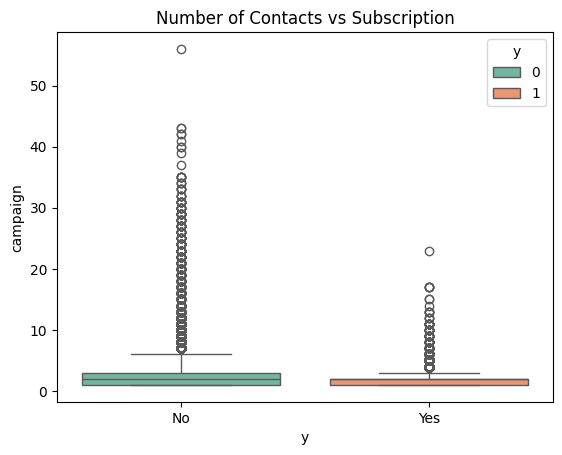

In [12]:
# 3. Campaign Contacts vs Subscription
# shows if number of contacts affects subscription
fig, ax = plt.subplots()
sns.boxplot(data=df, x='y', y='campaign', hue='y', palette='Set2', ax=ax)
ax.set_title('Number of Contacts vs Subscription')
ax.set_xticklabels(['No', 'Yes'])
plt.show()

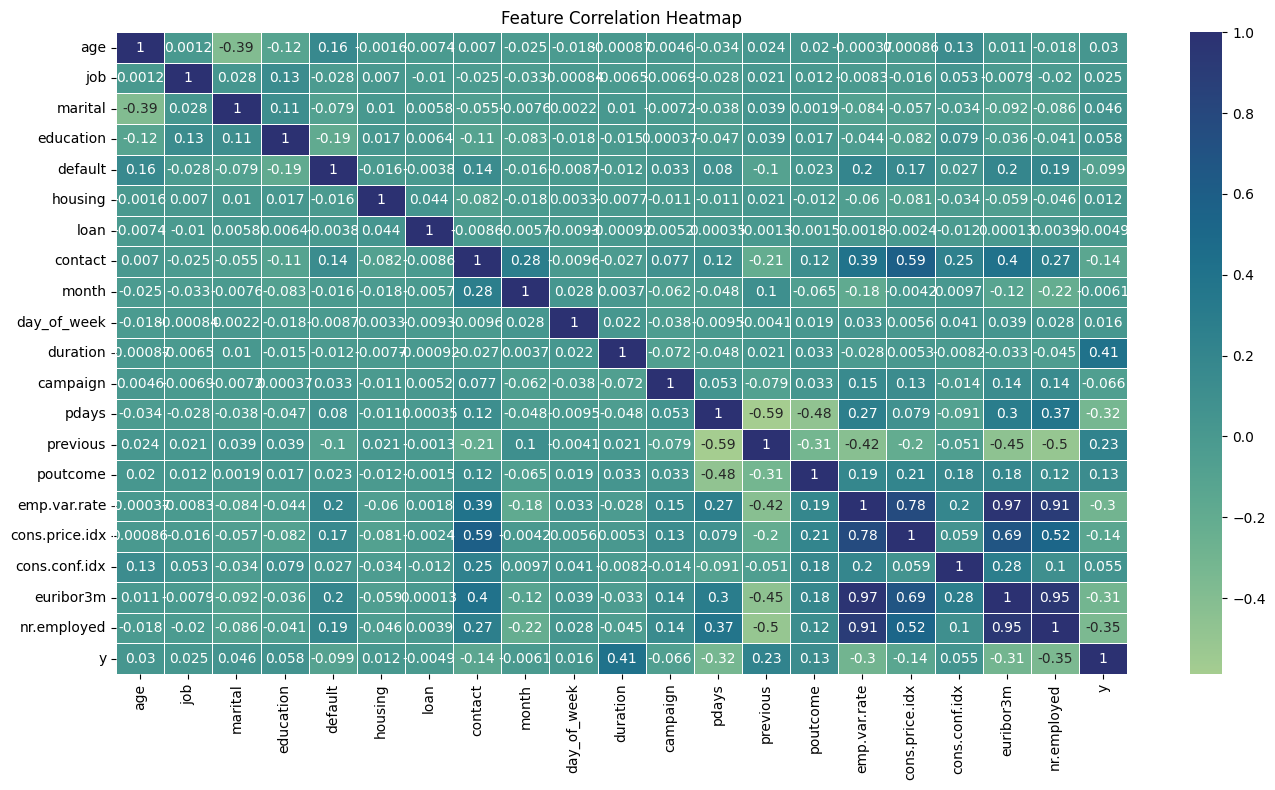

In [20]:
# 4. Correlation Heatmap
fig, ax = plt.subplots(figsize=(14,8))
sns.heatmap(df.corr(), annot=True, cmap='crest', ax=ax, linewidth=.5)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Train & Evaluate Model

In [21]:
# X = features, y = target
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Size:" , X_train.shape)
print("Testing Size:" , X_test.shape)

Training Size: (32950, 20)
Testing Size: (8238, 20)


In [22]:
# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")


Model trained successfully!


Accuracy: 0.9133284777858703
F1-Score: 0.5729665071770335


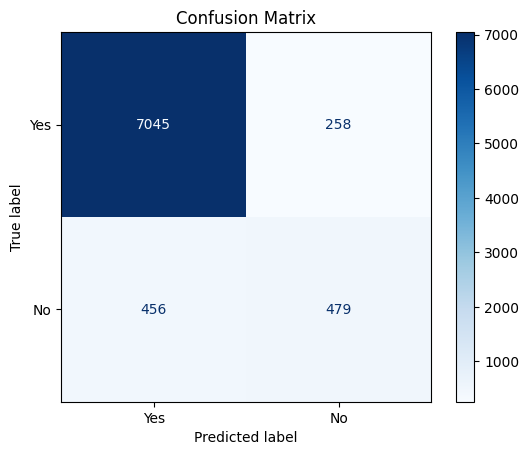

In [25]:
# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# F1-Score
print("F1-Score:", f1_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Yes', 'No']).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


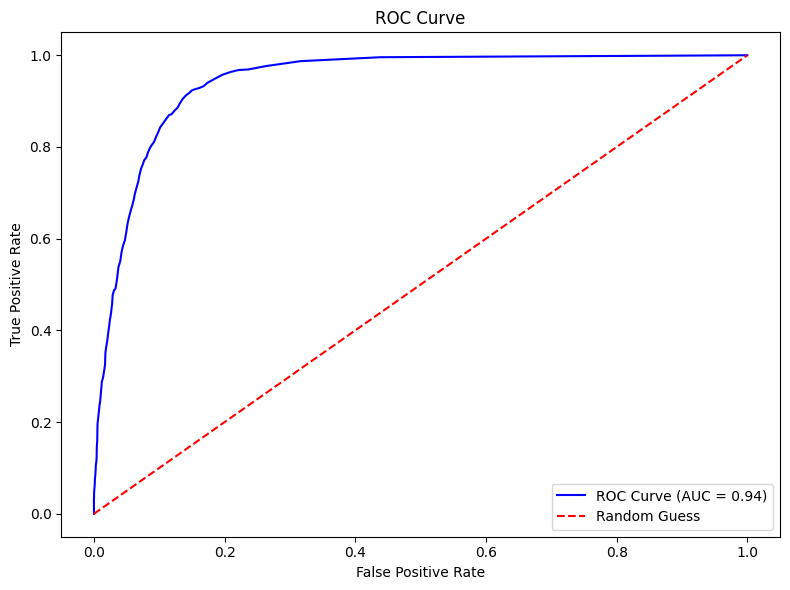

AUC Score: 0.94341443447532


In [26]:
# ROC Curve
y_prob = model.predict_proba(X_test)[:, 1]  # probability of "Yes"

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

print("AUC Score:", roc_auc)

# SHAP

In [27]:
# Create SHAP explainer using our trained Random Forest model
explainer = shap.TreeExplainer(model)
X_sample = X_test[:100]

# Calculate SHAP values
shap_values = explainer.shap_values(X_sample)

print("SHAP values calculated successfully!")
print("Shape of SHAP values:", shap_values.shape)

SHAP values calculated successfully!
Shape of SHAP values: (100, 20, 2)


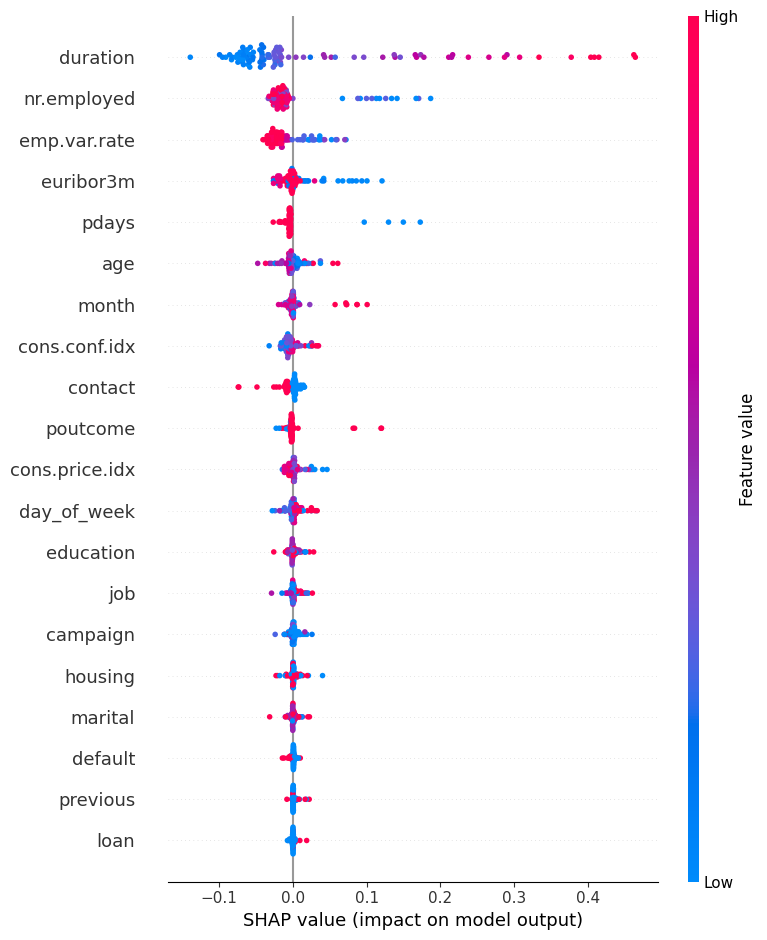

In [28]:
# Summary plot — shows which features impact predictions the most
shap.summary_plot(shap_values[:, :, 1], X_sample, feature_names=X.columns.tolist())

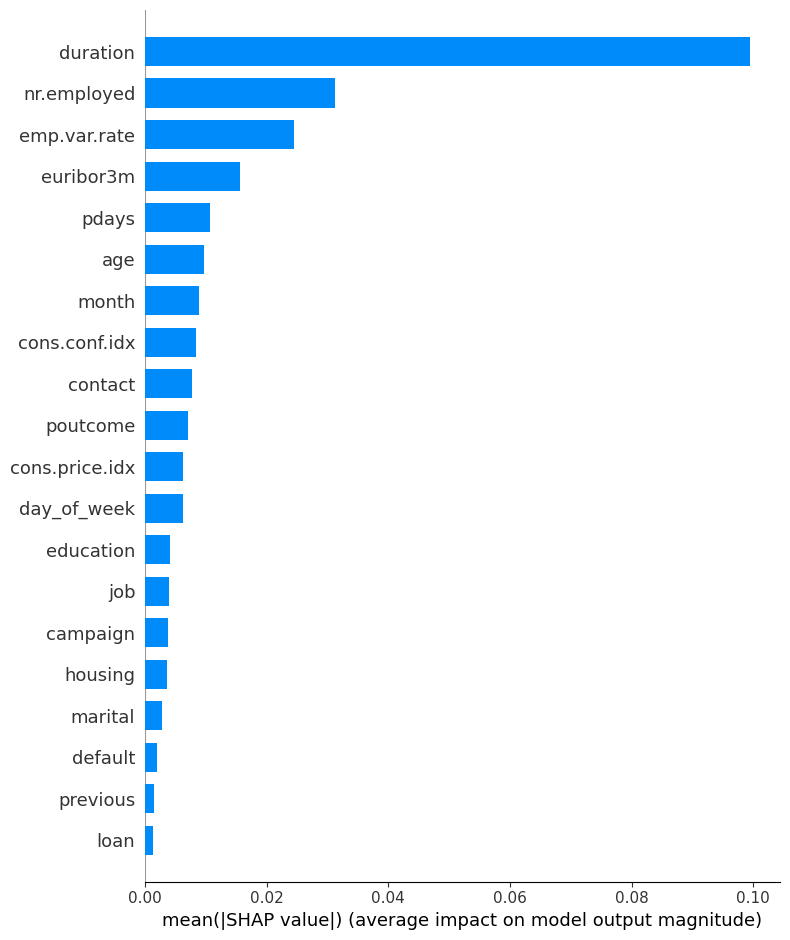

In [29]:
# Bar plot — average impact of each feature
shap.summary_plot(shap_values[:, :, 1], X_sample,
                  feature_names=X.columns.tolist(),
                  plot_type='bar')

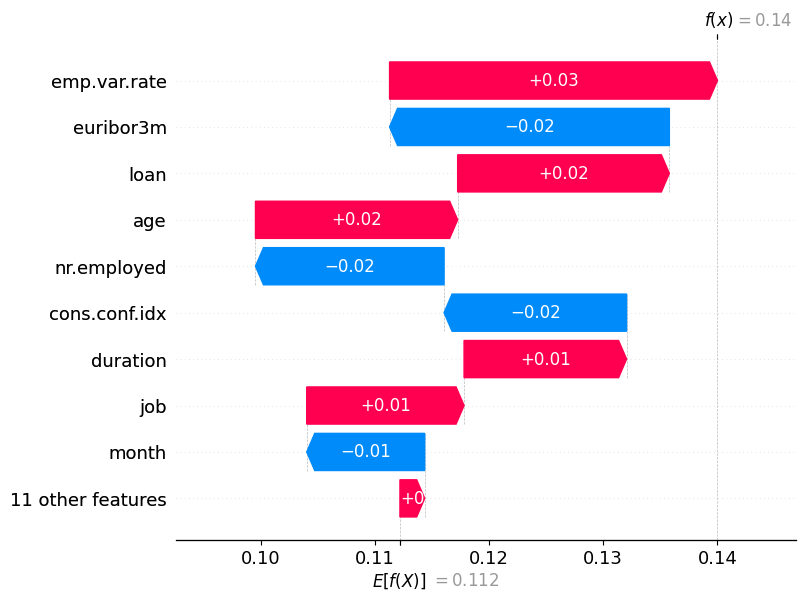

In [32]:
# Explain prediction for 1 customer (first customer in sample)
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0, :, 1],
    base_values=explainer.expected_value[1],
    feature_names=X.columns.tolist()
))


Customer 1 Explanation:


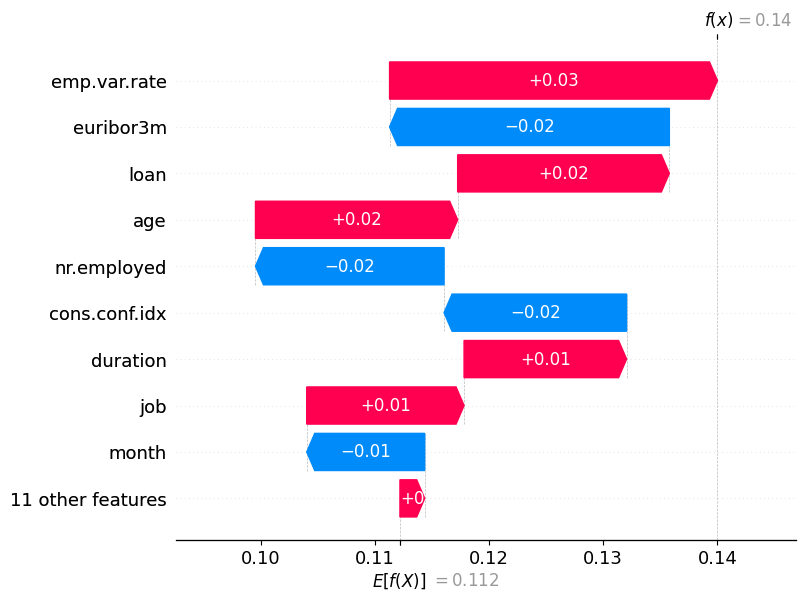


Customer 2 Explanation:


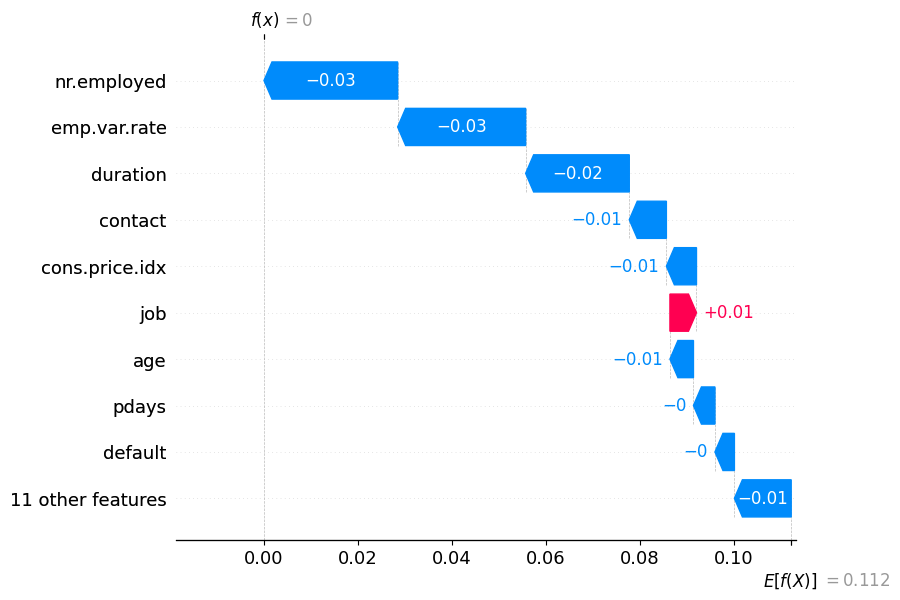


Customer 3 Explanation:


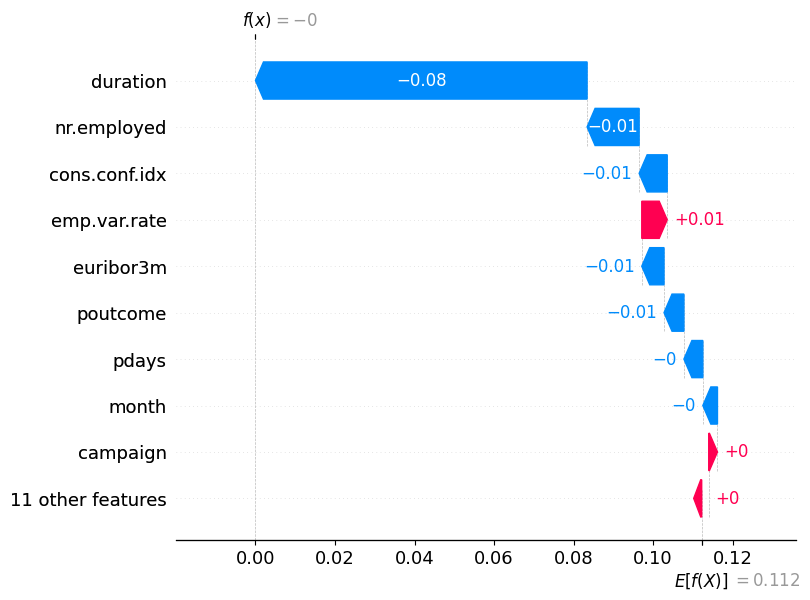


Customer 4 Explanation:


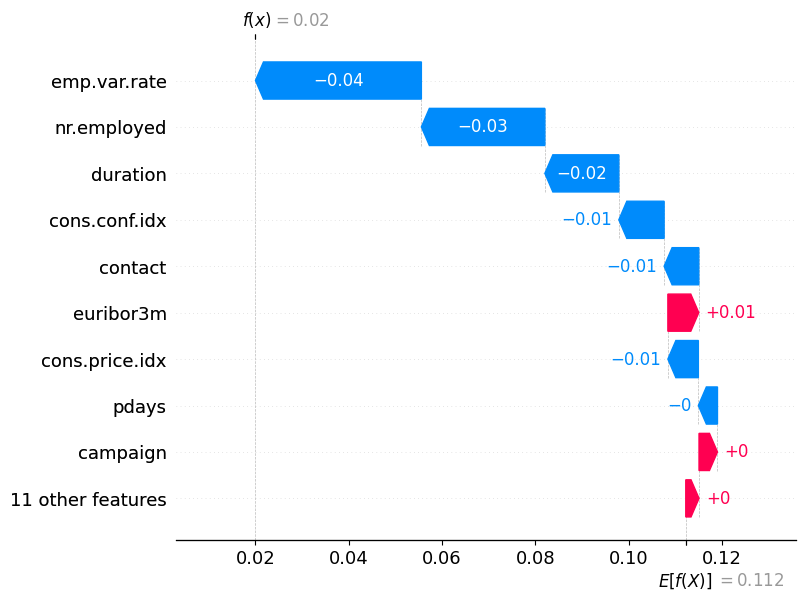


Customer 5 Explanation:


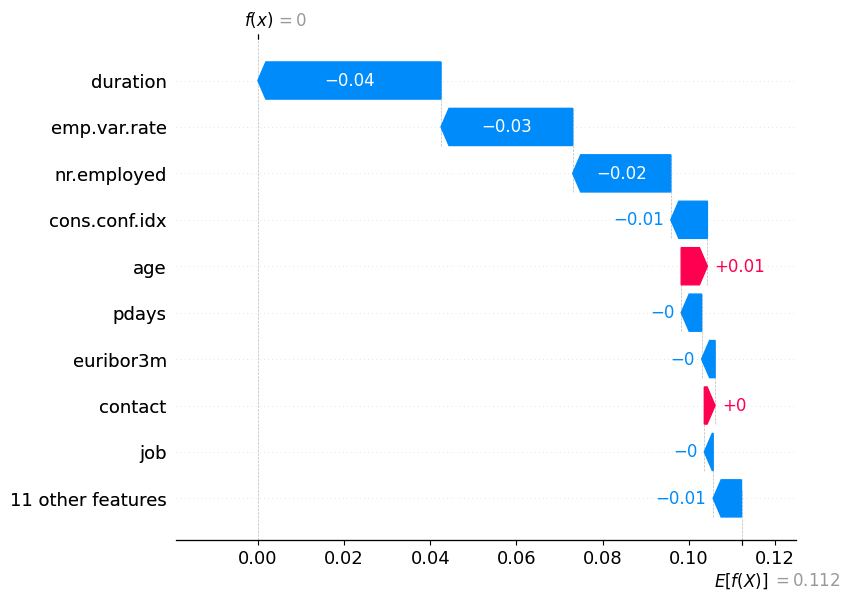

In [33]:
# Explain 5 individual predictions
for i in range(5):
    print(f"\nCustomer {i+1} Explanation:")
    shap.plots.waterfall(shap.Explanation(
        values=shap_values[i, :, 1],
        base_values=explainer.expected_value[1],
        feature_names=X.columns.tolist()
    ))

# Conclusion

- Dataset had no missing values but was highly imbalanced (88% No, 11% Yes)
- Random Forest achieved 91.33% accuracy and AUC score of 0.94
- F1 Score of 0.57 reflects class imbalance challenge
- ROC Curve confirmed excellent model discrimination ability (AUC = 0.94)
- SHAP analysis revealed:
  - Duration (call length) is the strongest predictor of subscription
  - Higher nr.employed and emp.var.rate push predictions toward No
  - Economic indicators significantly influence customer decisions
- Model explains individual predictions using SHAP waterfall plots
- Future improvement: apply class balancing (SMOTE) to improve F1 Score